# Data Exploration Before Encoding

In [ ]:
pip install -r requirements.txt

In [3]:
# Loading World Values Survey data raw
import os
import pandas as pd

df_wvs = pd.read_csv('../data/raw/wvs_ts_w1_w7.csv')

# Exploration of the WVS to have more information on how to impute missing values

In [4]:
print(df_wvs.head(5))

              version                        doi  S001  S002VS  S003  \
0  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       3     8   
1  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       3     8   
2  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       3     8   
3  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       3     8   
4  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       3     8   

  COUNTRY_ALPHA  COW_NUM COW_ALPHA  S004  S006  ...     Y023A     Y023B  \
0           ALB      339       ALB     1     1  ...  0.000000  0.444444   
1           ALB      339       ALB     1     2  ...  0.111111  0.444444   
2           ALB      339       ALB     1     3  ...  0.000000  0.444444   
3           ALB      339       ALB     1     4  ...  0.000000  0.333333   
4           ALB      339       ALB     1     5  ...  0.000000  0.333333   

      Y023C  Y024A  Y024B  Y024C  survself  tradrat5   TradAgg  SurvSAgg  
0  0.444444   0.33    0.0  0.165 -1.01127

In [5]:
import json
import pandas as pd
import os

# Set the output directory
output_dir = "../data/processed/1_dataprep"

# Load the variable_dict.json file that contains the mapping of variable names
with open("variable_dict.json", "r", encoding="utf-8") as file:
    variable_dict = json.load(file)

# Extract the column names from the dictionary (we only need the keys from the dictionary)
selected_columns = list(variable_dict.keys())

# Renaming column names
new_df = df_wvs.rename(columns={
    "COUNTRY_ALPHA": "country",
    "S020": "year",
    "S002VS": "wave",
    "X001": "sex",
    "X003R": "age_6",
    "X025CSWVS": "education_c",
    "X025R": "education_l"
})

# Filter rows for waves 4 to 7 
df_selected = new_df[new_df["wave"].isin([4, 5, 6, 7])].copy()

# Define core columns to retain
core_columns = ["country", "year", "wave", "sex", "age_6", "education_c", "education_l"]

# Final list of columns to keep
selected_columns = core_columns + list(variable_dict.keys())

# Subset the data
df_selected = df_selected[selected_columns]

# Get countries that appear in at least 3 of the 4 waves
wave_counts = df_selected.groupby("country")["wave"].nunique()
eligible_countries = wave_counts[wave_counts >= 3].index
df_selected = df_selected[df_selected["country"].isin(eligible_countries)].copy()

# Save cleaned dataset
output_path = os.path.join(output_dir, "wvs_filtered_waves4to7.csv")
df_selected.to_csv(output_path, index=False)

In [6]:
# Checking total number of countries
total_unique_countries = df_selected["country"].nunique()
print("Total unique countries:", total_unique_countries)

#Checking years
min_year = df_selected["year"].min()
max_year = df_selected["year"].max()

print("Min year:", min_year)
print("Max year:", max_year)

#Check for column names
df_selected.columns[:10]
print("Column names:", df_selected.columns.tolist())

# Check dimension of dataframe
print("Shape of the filtered DataFrame:", df_selected.shape)

Total unique countries: 43
Min year: 1999
Max year: 2023
Column names: ['country', 'year', 'wave', 'sex', 'age_6', 'education_c', 'education_l', 'A124_02', 'A124_06', 'A124_07', 'A124_08', 'A124_09', 'C002', 'E036', 'E037', 'E039', 'F114A', 'F115', 'F116', 'F117', 'F118', 'F119', 'F120', 'F121', 'F122', 'F123', 'G006', 'E069_01', 'E069_02', 'E069_04', 'E069_05', 'E069_06', 'E069_07', 'E069_08', 'E069_13', 'E069_17']
Shape of the filtered DataFrame: (229263, 36)


## Missing Values per Country per Wave

/var/folders/vk/c6csf7ws6pj9wy406twfjkfw0000gn/T/ipykernel_45649/2558341649.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_percentage_matrix = df_selected.groupby(["country", "wave"]).apply(missing_percentage).unstack(fill_value=0)


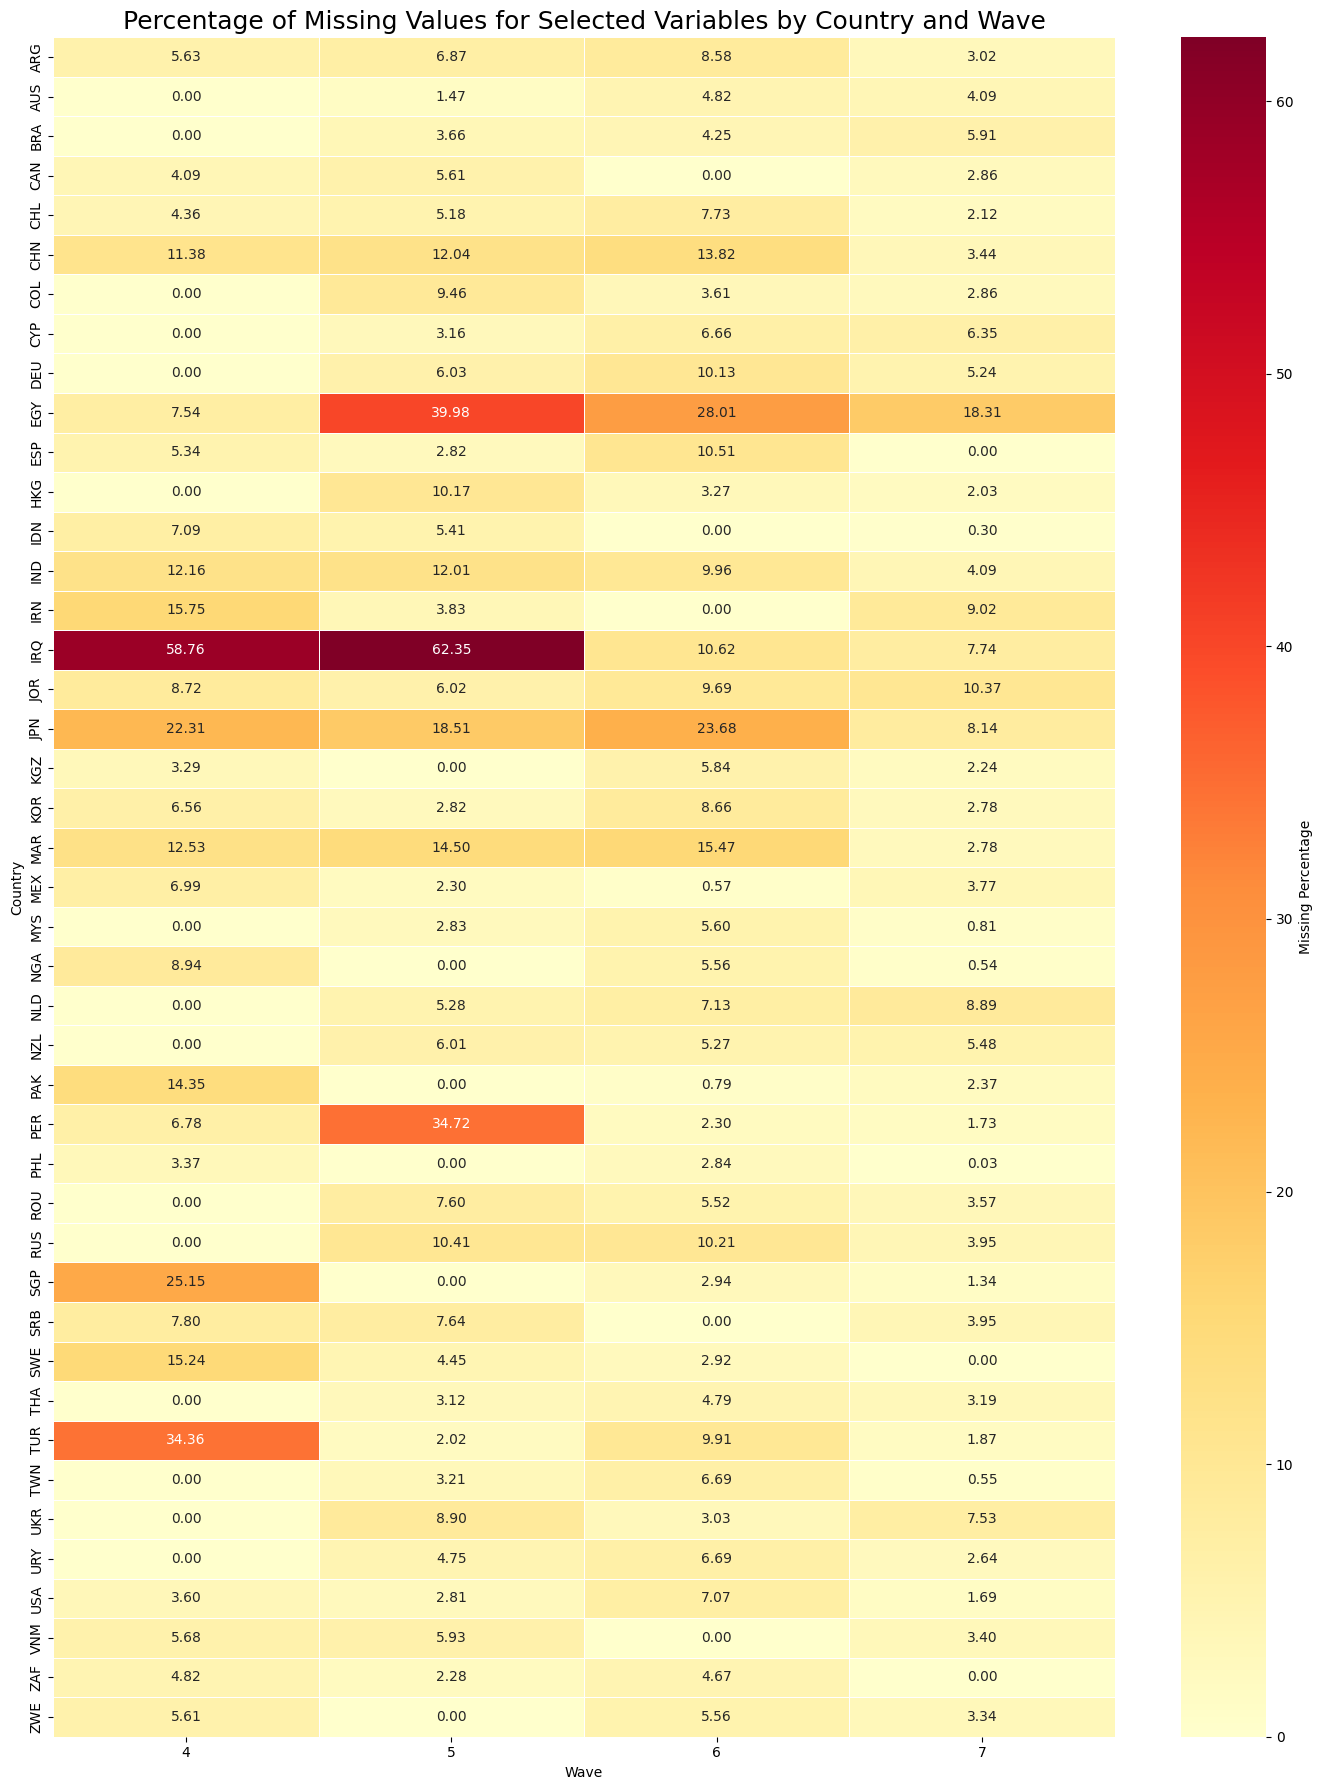

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

# Load the iso_country_map JSON file
with open("iso_country.json", "r", encoding="utf-8") as file:
    iso_country_map = json.load(file)

# Calculate missing percentage for each (country, wave)
def missing_percentage(group):
    total_values = group.shape[0] * group.shape[1]
    negative_values = (group.select_dtypes(include='number') < 0).sum().sum()
    return (negative_values / total_values) * 100

# Group by country and wave, then compute missing percentage
missing_percentage_matrix = df_selected.groupby(["country", "wave"]).apply(missing_percentage).unstack(fill_value=0)

# Plot the heatmap
plt.figure(figsize=(14, 18))
sns.heatmap(
    missing_percentage_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Missing Percentage'}
)

plt.title("Percentage of Missing Values for Selected Variables by Country and Wave", fontsize=18)
plt.xlabel("Wave")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


## Presence of Countries per Wave

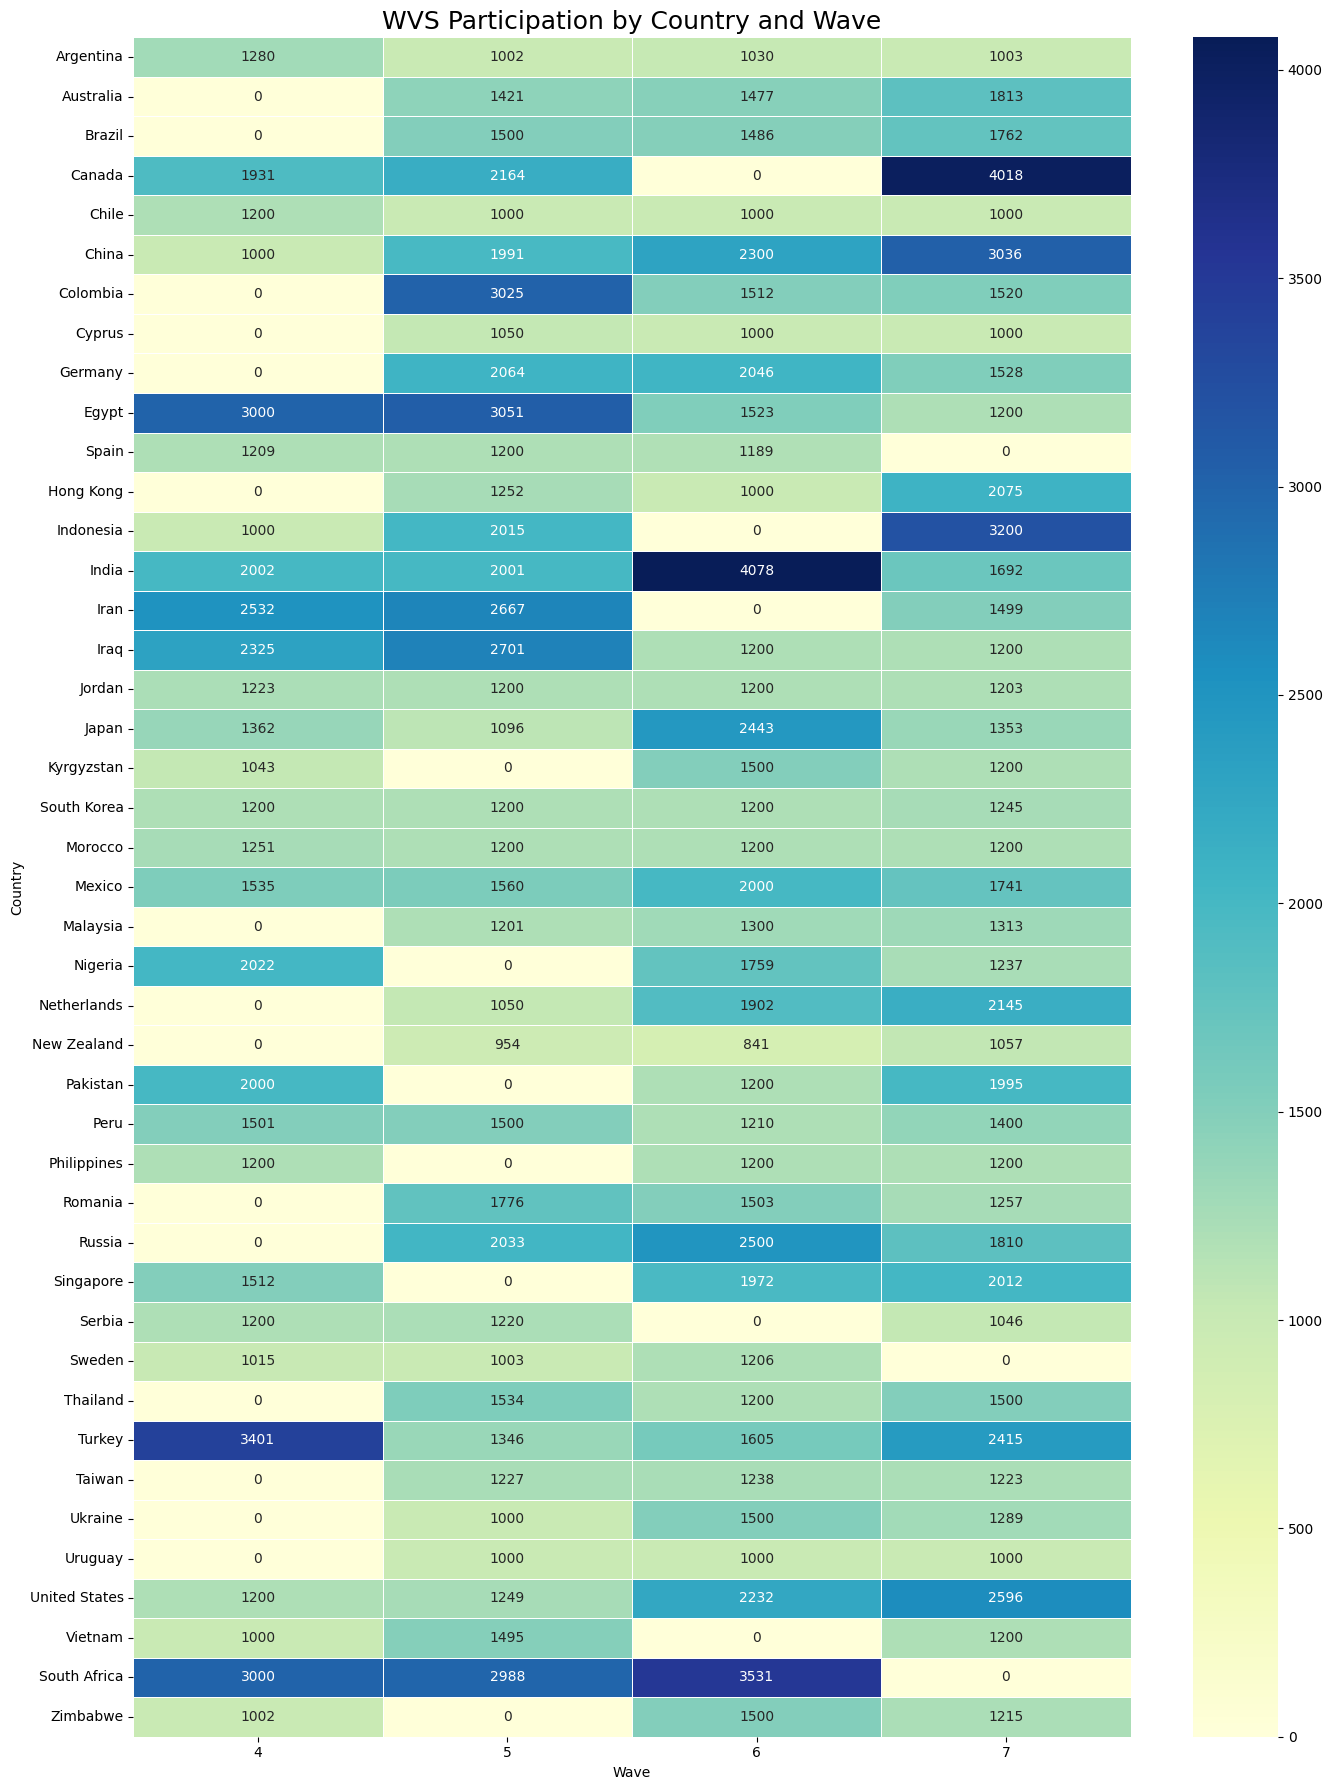

In [8]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

# Load the pre-filtered data with waves 4 to 7
df = pd.read_csv('../data/processed/1_dataprep/wvs_filtered_waves4to7.csv')

# Create participation matrix (number of respondents per country per wave)
participation_matrix = df.groupby(["country", "wave"]).size().unstack(fill_value=0)

# Load ISO to full country name mapping from JSON
with open("iso_country.json", "r", encoding="utf-8") as f:
    iso_to_full = json.load(f)

# Map ISO codes to full country names
participation_matrix["Country Name"] = participation_matrix.index.map(iso_to_full)
participation_matrix = participation_matrix.set_index("Country Name")

# Step 4: Plot the heatmap
plt.figure(figsize=(14, 18))
sns.heatmap(participation_matrix, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)

plt.title("WVS Participation by Country and Wave", fontsize=18)
plt.xlabel("Wave")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## Exploring demographics

### Age

<Figure size 1200x800 with 0 Axes>

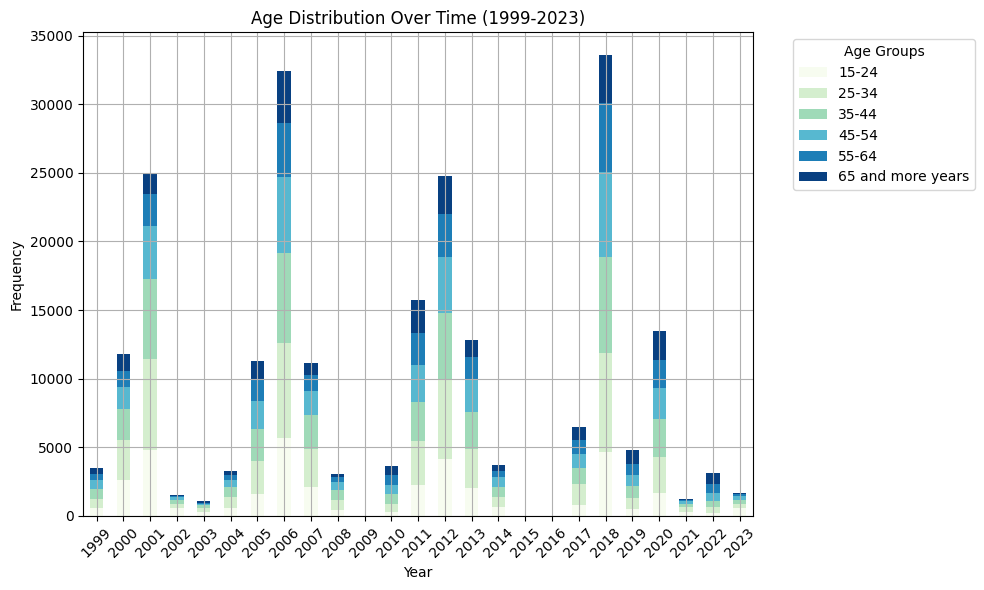

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


# Relabeling of intervals
value_labels = {
    1: "15-24",
    2: "25-34",
    3: "35-44",
    4: "45-54",
    5: "55-64",
    6: "65 and more years",
    -1: "Don't know",
    -2: "No answer",
    -4: "Not asked",
    -5: "Other missing; Multiple answers Mail (EVS)"
}

# Replace the values with the labels
df_selected["age_6"] = df_selected["age_6"].replace(value_labels)

# Drop missing values for X003R (including labels -1, -2, -4, -5)
df_wvs_clean = df_selected[~df_selected["age_6"].isin(["Don't know", "No answer", "Not asked", "Other missing; Multiple answers Mail (EVS)"])]

# Ensure that all years from 1989 to 2023 are included, even if some years have no data
years_range = list(range(1999, 2024))

# Group by year  and age interval  and calculate the counts
age_distribution_by_year = df_wvs_clean.groupby(['year', 'age_6']).size().unstack(fill_value=0)

# Reindex to ensure all years from 1989 to 2023 are included, filling missing years with 0 counts
age_distribution_by_year = age_distribution_by_year.reindex(years_range, fill_value=0)

# Plot the distribution of age intervals over time (1989-2023)
plt.figure(figsize=(12, 8))
age_distribution_by_year.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='GnBu')

# Adding labels and title
plt.title("Age Distribution Over Time (1999-2023)")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.legend(title="Age Groups", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()  # Adjusting labels for them not to be cut off

# Show the plot
plt.show()

/var/folders/vk/c6csf7ws6pj9wy406twfjkfw0000gn/T/ipykernel_45649/2119408911.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_distribution_by_year_group = df_selected.groupby(['Year_Group', 'age_6']).size().unstack(fill_value=0)


<Figure size 1200x800 with 0 Axes>

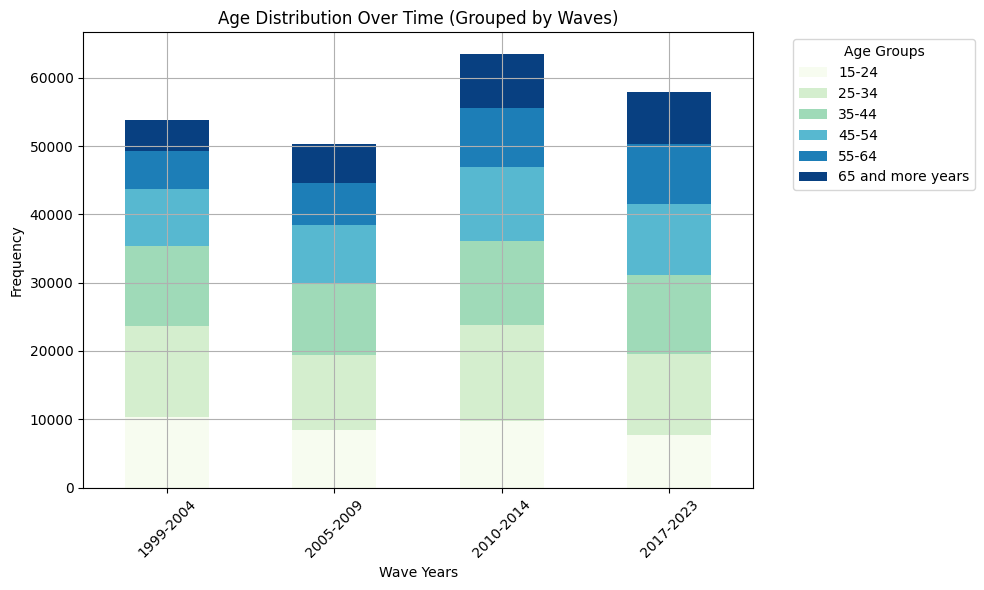

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Relabeling of intervals
value_labels = {
    1: "15-24",
    2: "25-34",
    3: "35-44",
    4: "45-54",
    5: "55-64",
    6: "65 and more years",
    -1: "Don't know",
    -2: "No answer",
    -4: "Not asked",
    -5: "Other missing; Multiple answers Mail (EVS)"
}

# Replace the values with the labels
df_selected["age_6"] = df_selected["age_6"].replace(value_labels)

# Drop missing values for X003R (including labels -1, -2, -4, -5)
df_selected = df_selected[~df_selected["age_6"].isin(["Don't know", "No answer", "Not asked", "Other missing; Multiple answers Mail (EVS)"])]

# Define the year intervals by waves 4 to 7

year_bins = [1999, 2005, 2010, 2017, 2023]  # waves 4 to 7
year_labels = ["1999-2004", "2005-2009", "2010-2014", "2017-2023"]  # Labels match the number of bins - 1

# Group years into bins
df_selected['Year_Group'] = pd.cut(df_selected['year'], bins=year_bins, labels=year_labels, right=True)

# Group by year range and age interval (X003R) and calculate the counts
age_distribution_by_year_group = df_selected.groupby(['Year_Group', 'age_6']).size().unstack(fill_value=0)

# Plot the distribution of age intervals over time (1999-2023) by grouped years
plt.figure(figsize=(12, 8))
age_distribution_by_year_group.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='GnBu')

# Adding labels and title
plt.title("Age Distribution Over Time (Grouped by Waves)")
plt.xlabel("Wave Years")
plt.ylabel("Frequency")

# Adding legend and grid
plt.legend(title="Age Groups", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()  # To adjust layout so labels don't get cut off

# Show the plot
plt.show()
